# U-Net 이미지 분할 — 합성 데이터 전용 (2시간 강의용)

**목표**: 복잡한 실제 위성/항공 데이터 없이, 코드로 만든 **합성 데이터**만으로
U-Net의 원리와 이미지 분할(Segmentation)을 처음부터 끝까지 이해합니다.

**이미지 분류 vs 이미지 분할**
- 이미지 분류: "이 사진은 고양이" → 사진 1장에 라벨 1개
- 이미지 분할: "이 픽셀은 건물, 저 픽셀은 물" → **픽셀 하나하나를 분류**
- 즉 분할 = **픽셀 단위 다중분류**. 그래서 출력이 `(높이, 너비, 클래스수)` 형태가 됩니다.

**클래스(4개)**: `0 배경` · `1 건물` · `2 물` · `3 숲`

**실행 순서**: `런타임 → 모두 실행` (GPU 권장이지만 CPU로도 몇 분이면 끝납니다)

## 0. 라이브러리 임포트 · 설정

In [15]:
# matplotlib 한글 폰트 (Colab). import 한 줄로 적용됨.
!pip -q install koreanize-matplotlib

import numpy as np                              # 수치 연산
import tensorflow as tf                         # 딥러닝
from tensorflow.keras import layers, Model      # 레이어 / 모델 API
import matplotlib.pyplot as plt                 # 시각화
try:
    import koreanize_matplotlib                 # import 만으로 한글 폰트 자동 적용
except Exception:
    print("한글 폰트 생략 (그래프 한글이 깨질 수 있음)")
    

%matplotlib inline

# 재현성: 시드 고정 → 실행할 때마다 같은 결과
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

# ===== 하이퍼파라미터 =====
IMG_SIZE    = 128    # 이미지 한 변 크기 (128 x 128)
NUM_CLASSES = 4      # 0 배경, 1 건물, 2 물, 3 숲
BATCH_SIZE  = 16     # 한 번에 처리할 이미지 수
EPOCHS      = 30     # 학습 반복 횟수

CLASS_NAMES  = ["배경", "건물", "물", "숲"]
# 시각화용 색 (배경=회록, 건물=빨강, 물=파랑, 숲=초록)
CLASS_COLORS = np.array([[180,200,160],[220,60,60],[50,110,220],[30,120,40]], np.uint8)

print("TF 버전:", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
TF 버전: 2.15.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. 합성 데이터 만들기

색칠된 도형(사각형 = 건물·숲, 원 = 물)을 배경 위에 무작위로 그려서
**입력 이미지**와 **정답 마스크**를 동시에 만듭니다.

- **입력 이미지**: 색 + 약간의 노이즈 (진짜 항공사진 흉내)
- **정답 마스크**: 각 픽셀에 클래스 번호(0~3)를 적어둔 `(H, W)` 정수 배열

> 도형을 그릴 때 이미지와 마스크를 **함께** 칠하므로, 정답이 어긋날 일이 없습니다.

이미지: (300, 128, 128, 3) | 마스크: (300, 128, 128) | 라벨 종류: [0 1 2 3]


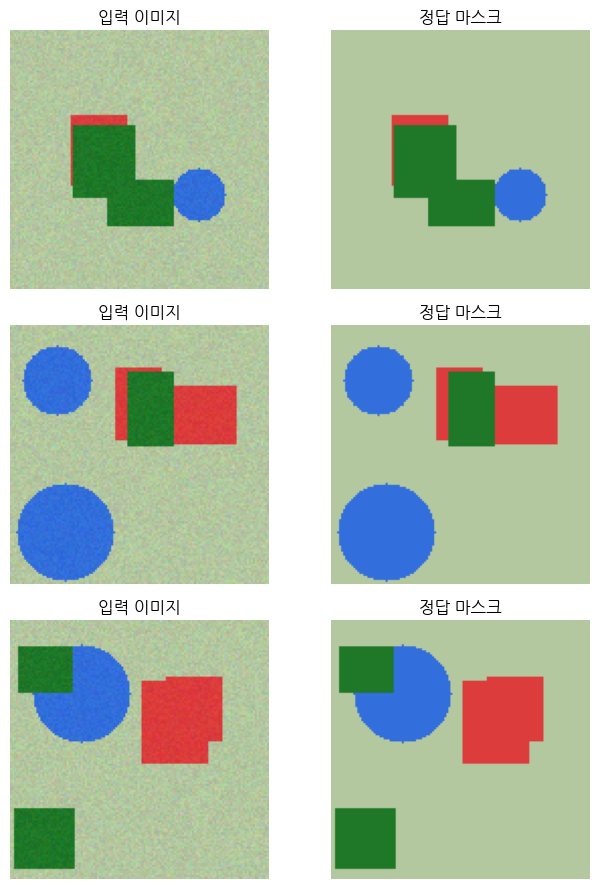

In [16]:
def draw_rect(img, msk, cls, color, rng, size):
    # 무작위 위치·크기의 사각형을 이미지와 마스크에 함께 그림
    w = int(rng.integers(size//6, size//3))
    h = int(rng.integers(size//6, size//3))
    x = int(rng.integers(0, size - w))
    y = int(rng.integers(0, size - h))
    img[y:y+h, x:x+w] = color      # 이미지: 색칠
    msk[y:y+h, x:x+w] = cls        # 마스크: 클래스 번호 기록

def draw_circle(img, msk, cls, color, rng, size):
    # 무작위 위치·반지름의 원을 그림 (거리 계산으로 원 안쪽을 찾음)
    r  = int(rng.integers(size//10, size//5))
    cx = int(rng.integers(r, size - r))
    cy = int(rng.integers(r, size - r))
    yy, xx = np.ogrid[:size, :size]                 # 좌표 격자
    inside = (xx - cx)**2 + (yy - cy)**2 <= r*r     # 원 안쪽이면 True
    img[inside] = color
    msk[inside] = cls

def make_synthetic(n, size):
    # 색칠된 도형으로 항공사진 + 정답마스크를 흉내낸 합성 데이터 생성
    rng = np.random.default_rng(SEED)
    imgs = np.zeros((n, size, size, 3), np.uint8)
    msks = np.zeros((n, size, size),    np.uint8)
    for i in range(n):
        # 배경(들판): 배경색 + 약간의 노이즈, 마스크는 전부 0(배경)에서 시작
        img = (CLASS_COLORS[0] + rng.integers(-12, 12, (size, size, 3))).clip(0, 255).astype(np.uint8)
        msk = np.zeros((size, size), np.uint8)
        for _ in range(int(rng.integers(1, 4))):   # 건물(사각형) 1~3개
            draw_rect(img, msk, 1, CLASS_COLORS[1], rng, size)
        for _ in range(int(rng.integers(1, 3))):   # 물(원) 1~2개
            draw_circle(img, msk, 2, CLASS_COLORS[2], rng, size)
        for _ in range(int(rng.integers(1, 3))):   # 숲(사각형) 1~2개
            draw_rect(img, msk, 3, CLASS_COLORS[3], rng, size)
        # 도형 위에도 약간의 노이즈 (마스크는 그대로)
        img = (img.astype(int) + rng.integers(-10, 10, (size, size, 3))).clip(0, 255).astype(np.uint8)
        imgs[i], msks[i] = img, msk
    return imgs, msks

# 데이터 생성
X, Y = make_synthetic(300, IMG_SIZE)
print("이미지:", X.shape, "| 마스크:", Y.shape, "| 라벨 종류:", np.unique(Y))

def colorize(mask):
    # (H,W) 클래스 라벨 -> (H,W,3) 색상 이미지 (보기 좋게)
    return CLASS_COLORS[mask]

# 샘플 3장: 입력 이미지 + 정답 마스크 확인
plt.figure(figsize=(7, 9))
for i in range(3):
    plt.subplot(3, 2, 2*i+1)
    plt.imshow(X[i])
    plt.axis("off")
    plt.title("입력 이미지")
    
    plt.subplot(3, 2, 2*i+2)
    plt.imshow(colorize(Y[i]))
    plt.axis("off")
    plt.title("정답 마스크")
    
plt.tight_layout(); plt.show()

## 2. 데이터 분할 & 입력 파이프라인

- **학습 240 / 검증 30 / 테스트 30**으로 나눕니다.
- 이미지는 **0~1로 정규화**, 마스크는 **정수 라벨 그대로**(절대 정규화 금지 — 라벨이 망가짐).
- `tf.data`로 배치를 만들어 학습을 빠르고 안정적으로 합니다.

In [ ]:
# ===== 학습 / 검증 / 테스트 분할 =====
a, b = 240, 270
Xtr, Ytr = X[:a],  Y[:a]     # 학습용
Xva, Yva = X[a:b], Y[a:b]    # 검증용 (학습 중 성능 확인)
Xte, Yte = X[b:],  Y[b:]     # 테스트용 (마지막 평가)
print(f"학습 {len(Xtr)} | 검증 {len(Xva)} | 테스트 {len(Xte)}")

def make_ds(imgs, masks, training):
    # 이미지 0~1 정규화, 마스크는 정수 그대로
    ds = tf.data.Dataset.from_tensor_slices(
        (imgs.astype("float32")/255.0, masks.astype("int32")))
    if training:
        ds = ds.shuffle(len(imgs), seed=SEED)   # 학습셋만 섞기
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)  # prefetch() 학습하는동안 다음 데이터 준비, AUTOTUNE: 자동결정

train_ds = make_ds(Xtr, Ytr, True)
val_ds   = make_ds(Xva, Yva, False)
test_ds  = make_ds(Xte, Yte, False)
print("파이프라인 준비 완료")

학습 240 | 검증 30 | 테스트 30
파이프라인 준비 완료


## 3. U-Net 구조

U-Net은 이름처럼 **U자 모양**입니다.

- **인코더(왼쪽, 수축)**: `Conv` + `MaxPooling`으로 크기를 절반씩 줄이며 "무엇이 있는지" 특징을 뽑음
- **병목(아래)**: 가장 압축된 특징
- **디코더(오른쪽, 확장)**: `UpSampling`으로 크기를 2배씩 키우며 "어디에 있는지" 위치를 복원
- **스킵 연결(skip connection)**: 인코더의 같은 크기 특징을 디코더에 `concatenate`로 이어붙임
  → 풀링으로 잃어버린 **세밀한 위치 정보**를 되살리는 U-Net의 핵심

크기 흐름: `128 → 64 → 32`(수축) → `32 → 64 → 128`(확장)
출력은 `Conv2D(클래스수, 1, softmax)` → **픽셀마다 4개 클래스 확률**.

In [18]:
def conv_block(x, filters):
    # Conv -> ReLU -> Conv -> ReLU : 특징 추출 기본 블록
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x

def build_unet(img_size, num_classes):
    inp = layers.Input((img_size, img_size, 3))

    # ----- 인코더(수축): 크기를 절반씩 줄이며 특징 추출 -----
    c1 = conv_block(inp, 16)           # 128x128x16   (스킵1로 저장)
    p1 = layers.MaxPooling2D(2)(c1)    # 64x64
    c2 = conv_block(p1, 32)            # 64x64x32     (스킵2로 저장)
    p2 = layers.MaxPooling2D(2)(c2)    # 32x32

    # ----- 병목: 가장 압축된 특징 -----
    bn = conv_block(p2, 64)            # 32x32x64

    # ----- 디코더(확장): 크기를 2배씩 키우며 스킵연결로 디테일 복원 -----
    u2 = layers.UpSampling2D(2)(bn)          # 32 -> 64
    u2 = layers.concatenate([u2, c2])        # 스킵연결 (인코더 c2 결합)
    u2 = conv_block(u2, 32)                  # 64x64x32
    u1 = layers.UpSampling2D(2)(u2)          # 64 -> 128
    u1 = layers.concatenate([u1, c1])        # 스킵연결 (인코더 c1 결합)
    u1 = conv_block(u1, 16)                  # 128x128x16

    # ----- 출력: 픽셀마다 클래스 확률 (softmax) -----
    out = layers.Conv2D(num_classes, 1, activation="softmax")(u1)  # 128x128x4
    return Model(inp, out, name="Simple-UNet")

model = build_unet(IMG_SIZE, NUM_CLASSES)
model.summary()

Model: "Simple-UNet"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 conv2d_22 (Conv2D)          (None, 128, 128, 16)         448       ['input_3[0][0]']             
                                                                                                  
 conv2d_23 (Conv2D)          (None, 128, 128, 16)         2320      ['conv2d_22[0][0]']           
                                                                                                  
 max_pooling2d_4 (MaxPoolin  (None, 64, 64, 16)           0         ['conv2d_23[0][0]']           
 g2D)                                                                                   

## 4. 컴파일 & 학습

- **loss = `sparse_categorical_crossentropy`**: 픽셀 하나하나가 4클래스 다중분류이고,
  정답 마스크가 **정수 라벨**이므로 `sparse_` 버전을 사용 (원-핫 변환 불필요).
- **optimizer = `adam`**: 무난한 기본 최적화 알고리즘.
- **metrics = `accuracy`**: 픽셀 정확도(맞힌 픽셀 비율).

In [19]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",   # 픽셀 단위 다중분류 + 정수 라벨
    metrics=["accuracy"],                      # 픽셀 정확도
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    shuffle=False,        # 이미 tf.data에서 섞었으므로 여기선 끔(불필요한 경고 방지)
    verbose=1,
)

Epoch 1/30
15/15 [==============================] - 3s 137ms/step - loss: 1.0143 - accuracy: 0.7014 - val_loss: 0.6341 - val_accuracy: 0.7651
Epoch 2/30
15/15 [==============================] - 1s 95ms/step - loss: 0.5285 - accuracy: 0.7465 - val_loss: 0.3835 - val_accuracy: 0.7652
Epoch 3/30
15/15 [==============================] - 1s 95ms/step - loss: 0.3749 - accuracy: 0.8332 - val_loss: 0.2846 - val_accuracy: 0.9082
Epoch 4/30
15/15 [==============================] - 1s 91ms/step - loss: 0.2229 - accuracy: 0.9111 - val_loss: 0.1490 - val_accuracy: 0.9117
Epoch 5/30
15/15 [==============================] - 2s 103ms/step - loss: 0.1161 - accuracy: 0.9620 - val_loss: 0.0674 - val_accuracy: 0.9763
Epoch 6/30
15/15 [==============================] - 1s 94ms/step - loss: 0.0537 - accuracy: 0.9816 - val_loss: 0.0285 - val_accuracy: 0.9907
Epoch 7/30
15/15 [==============================] - 1s 91ms/step - loss: 0.0287 - accuracy: 0.9907 - val_loss: 0.0185 - val_accuracy: 0.9950
Epoch 8/30


## 5. 학습 곡선

- **손실(loss)** 이 내려가고 **정확도(accuracy)** 가 올라가면 학습이 잘 되는 것.
- `train`과 `val` 곡선이 크게 벌어지지 않으면 과적합이 아님.

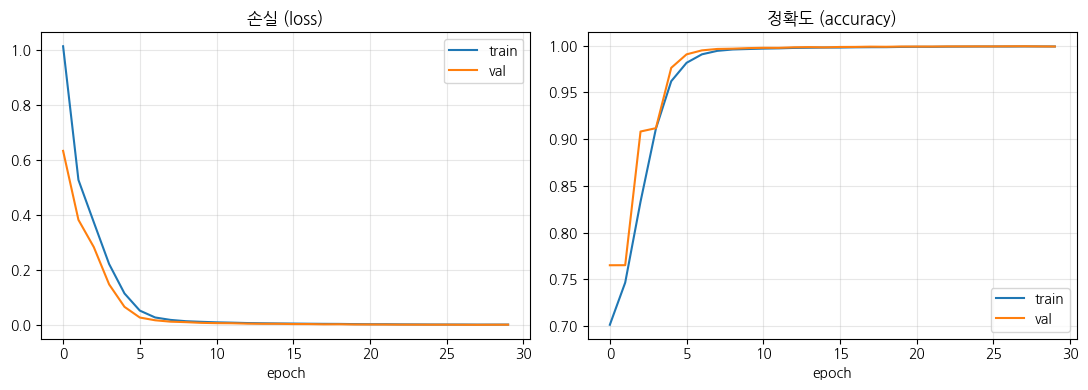

In [ ]:
h = history.history
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.plot(h["loss"],     label="train")
plt.plot(h["val_loss"], label="val")
plt.title("손실 (loss)"); plt.xlabel("epoch"); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(h["accuracy"],     label="train")
plt.plot(h["val_accuracy"], label="val")
plt.title("정확도 (accuracy)"); plt.xlabel("epoch"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. 결과 확인

테스트 이미지에 대해 **이미지 / 정답 / 예측**을 나란히 비교합니다.
합성 데이터는 규칙이 명확해서 예측이 정답과 거의 같게 나옵니다.

- `model.predict`는 픽셀마다 4개 확률을 반환 → `argmax`로 **가장 큰 확률의 클래스**를 고름.

[테스트] loss = 0.004   픽셀 정확도 = 0.999


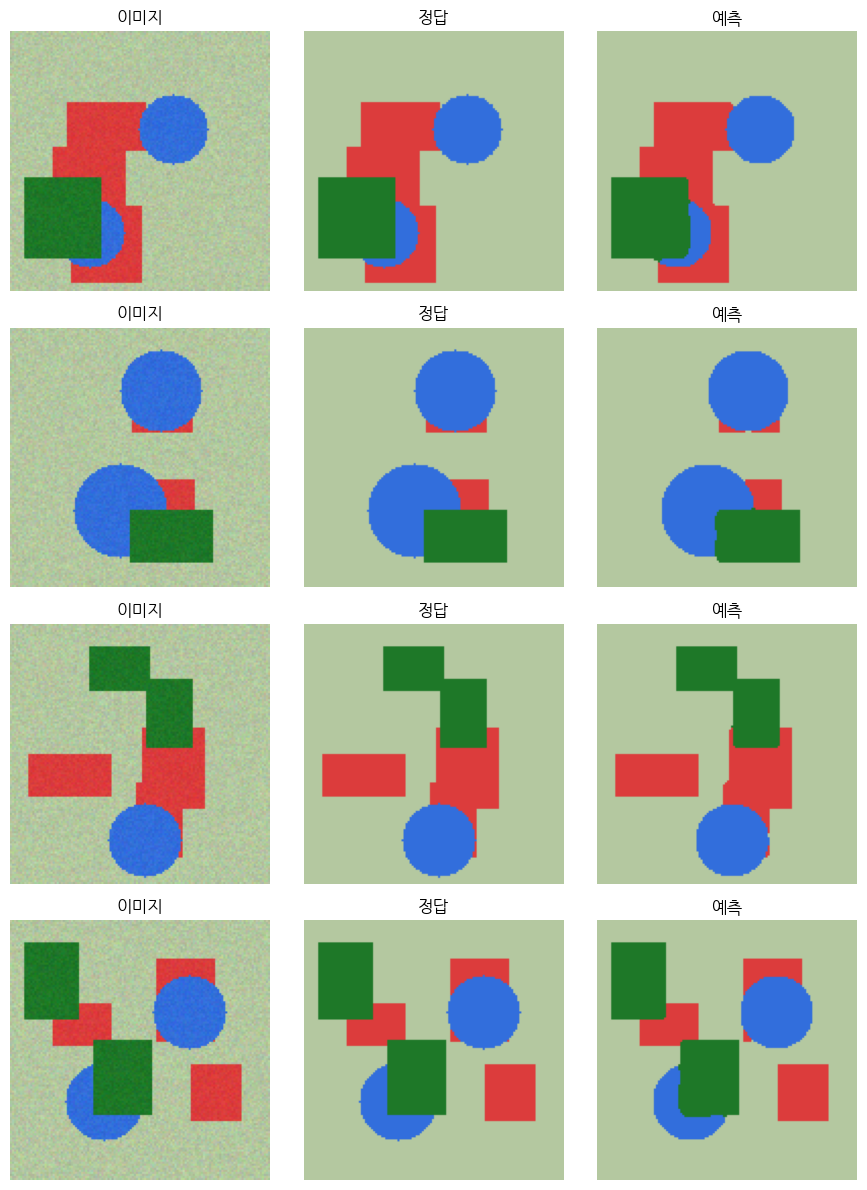

In [ ]:
# 테스트셋 전체 성능
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"[테스트] loss = {test_loss:.3f}   픽셀 정확도 = {test_acc:.3f}")

# 예측 결과 시각화: 이미지 / 정답 / 예측
for imgs, masks in test_ds.take(1):
    preds = np.argmax(model.predict(imgs, verbose=0), axis=-1)   # 확률 -> 라벨
    k = 4
    plt.figure(figsize=(9, 3*k))
    for i in range(k):
        plt.subplot(k, 3, 3*i+1)
        plt.imshow(imgs[i].numpy())        
        plt.axis("off")
        plt.title("이미지")
        
        plt.subplot(k, 3, 3*i+2)
        plt.imshow(colorize(masks[i].numpy().astype(np.uint8)))
        plt.axis("off")
        plt.title("정답")
        
        plt.subplot(k, 3, 3*i+3)
        plt.imshow(colorize(preds[i].astype(np.uint8)))
        plt.axis("off")
        plt.title("예측")
        
    plt.tight_layout()
    plt.show()
    break

## 마무리 — 핵심 정리

- **이미지 분할 = 픽셀 단위 다중분류** → 출력 `(H, W, 클래스수)`, 마지막 층은 `softmax`.
- **U-Net = 인코더(수축) + 병목 + 디코더(확장) + 스킵 연결**.
  스킵 연결(`concatenate`)이 풀링으로 잃은 **위치 디테일**을 복원하는 핵심.
- 인코더는 `Conv`+`MaxPooling`으로 **크기↓·채널↑**, 디코더는 `UpSampling`+`concat`으로 **크기↑**.
- **loss는 `sparse_categorical_crossentropy`** (정수 라벨 다중분류), 지표는 **픽셀 정확도**.
- 합성 데이터는 규칙이 명확 → **깨끗한 결과**. 실제 위성/항공 데이터는 노이즈·클래스 불균형 때문에
  더 어렵고, 그때는 **데이터 증강 · 클래스 가중치 · 전이학습(사전학습 인코더)** 등이 추가로 필요.

### 더 해볼 거리 (심화)
- 클래스를 5개로 늘리거나 가는 '도로'를 추가해 난이도 올리기
- `EPOCHS`를 줄였을 때/늘렸을 때 학습 곡선 비교
- 인코더 블록을 1단 더 쌓아 성능 변화 관찰